## misc analysis

In [1]:
import json
import sys
from datetime import datetime

def filter_posts_by_date(input_file_path, output_file_path, cutoff_date):
    """
    Filter JSONL file to keep only posts with dates on or before the cutoff date.
    
    Args:
        input_file_path (str): Path to the input JSONL file
        output_file_path (str): Path to the output JSONL file
        cutoff_date (str): Cutoff date in 'YYYY-MM-DD' format
    """
    try:
        # Convert cutoff date to datetime object for comparison
        cutoff_dt = datetime.strptime(cutoff_date, '%Y-%m-%d')
        
        filtered_count = 0
        total_count = 0
        
        with open(input_file_path, 'r', encoding='utf-8') as infile, \
             open(output_file_path, 'w', encoding='utf-8') as outfile:
            
            for line in infile:
                total_count += 1
                try:
                    # Parse the JSON object from the line
                    data = json.loads(line.strip())
                    
                    # Check if the post has a date field
                    if 'date' in data:
                        post_date_str = data['date']
                        
                        try:
                            # Convert post date to datetime object
                            post_dt = datetime.strptime(post_date_str, '%Y-%m-%d')
                            
                            # Check if post date is on or before cutoff date
                            if post_dt <= cutoff_dt:
                                # Write the original line to output file
                                outfile.write(line)
                                filtered_count += 1
                                
                        except ValueError:
                            print(f"Warning: Invalid date format '{post_date_str}' in line {total_count}")
                            continue
                    else:
                        print(f"Warning: No 'date' field found in line {total_count}")
                        
                except json.JSONDecodeError as e:
                    print(f"Error parsing JSON on line {total_count}: {e}")
                    continue
        
        print(f"Processing complete!")
        print(f"Total posts processed: {total_count}")
        print(f"Posts kept (on or before {cutoff_date}): {filtered_count}")
        print(f"Posts filtered out: {total_count - filtered_count}")
        print(f"Filtered results saved to: {output_file_path}")
        
    except FileNotFoundError:
        print(f"Error: Input file '{input_file_path}' not found.")
    except ValueError as e:
        print(f"Error: Invalid cutoff date format. Please use 'YYYY-MM-DD' format. Error: {e}")
    except Exception as e:
        print(f"Error processing files: {e}")

if __name__ == "__main__":
    # Configuration - update these paths as needed
    input_jsonl_file = "teamblind_layoffs_posts_and_comments.jsonl"  # Replace with your input file path
    output_jsonl_file = "teamblind_layoffs_posts_and_comments_new.jsonl"  # Output file name
    cutoff_date = "2025-04-30"  # Cutoff date
    
    # Filter the posts
    filter_posts_by_date(input_jsonl_file, output_jsonl_file, cutoff_date)

Processing complete!
Total posts processed: 9399
Posts kept (on or before 2025-04-30): 9219
Posts filtered out: 180
Filtered results saved to: teamblind_layoffs_posts_and_comments_new.jsonl


In [2]:
import json

total_comments = 0

with open('teamblind_layoffs_posts_and_comments_new.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        total_comments += data.get('commentCount', 0)

print(f"Total commentCount: {total_comments}")

Total commentCount: 252494


In [3]:
import json

authors = set()

with open('teamblind_layoffs_posts_and_comments_new.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        if 'author' in data:
            authors.add(data['author'])

print(f"Unique authors: {len(authors)}")

Unique authors: 6993


## flair analysis on fednews

In [2]:
import json

def get_unique_link_flair_text(file_path):
    """
    Extract unique values of the 'link_flair_text' key from a JSONL file.

    Args:
        file_path (str): Path to the JSONL file.

    Returns:
        set: A set of unique values for the 'link_flair_text' key.
    """
    unique_flair_texts = set()

    # Load the JSONL file
    with open(file_path, 'r') as file:
        for line in file:
            data = json.loads(line)
            if 'link_flair_text' in data:
                unique_flair_texts.add(data['link_flair_text'])

    return unique_flair_texts

# Example usage
flairwise_posts_files = [
    'fednews_posts.jsonl'
]

for file in flairwise_posts_files:
    print(f"Processing file: {file}")
    unique_flairs = get_unique_link_flair_text(file)
    print(f"Unique link_flair_text values in {file}:")
    for flair in unique_flairs:
        print(flair)

Processing file: fednews_posts.jsonl
Unique link_flair_text values in fednews_posts.jsonl:
None
HR
:StMayorkas_coin: Early Release | Time Off
META
im a 🤡 
News / Article
:OPM_seal: Pay & Benefits
:Army_starmark: Verified News Organization  :Army_starmark:
Announcement
Budget
Daily Discussion Megathread
im an idiot that got shadowbanned for this post
Fed only
🔒 
Use the MEGATHREAD next time please
Unverified Org/Person
Misc Question
idiot of the morning


Processing file: fednews_posts.jsonl
Subreddit name: fednews_posts.jsonl
Monthly trend saved to fednews_posts_monthly_trend.csv


/tmp/ipykernel_250437/1895809902.py:67: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250437/1895809902.py:67: UserWarning: Glyph 129313 (\N{CLOWN FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_250437/1895809902.py:70: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig(output_plot)
/tmp/ipykernel_250437/1895809902.py:70: UserWarning: Glyph 129313 (\N{CLOWN FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_plot)


Plot saved to fednews_posts_monthly_trend.png


/home/csgrads/shahr072/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/csgrads/shahr072/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129313 (\N{CLOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


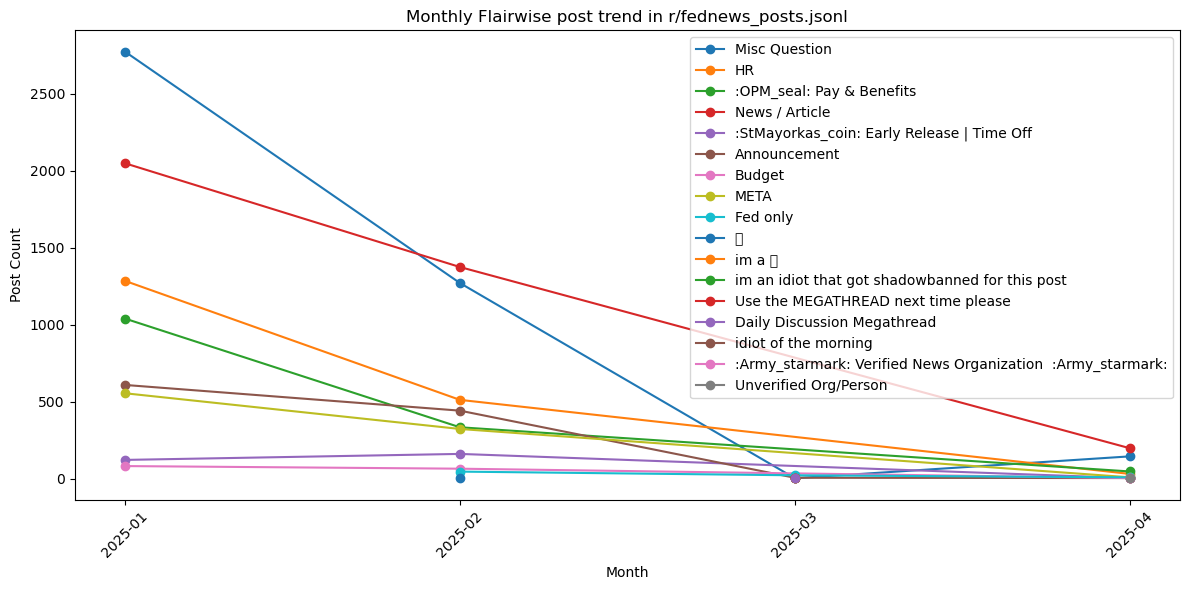

In [3]:
import json
import pandas as pd
from collections import defaultdict
from datetime import datetime
import matplotlib.pyplot as plt

def get_monthly_trend(file_path):
    """
    Calculate the monthly trend for each flair in a JSONL file.

    Args:
        file_path (str): Path to the JSONL file.

    Returns:
        dict: A dictionary where keys are flairs and values are dictionaries
              with months as keys and counts as values.
    """
    monthly_trend = defaultdict(lambda: defaultdict(int))

    # Load the JSONL file
    with open(file_path, 'r') as file:
        for line in file:
            data = json.loads(line)
            if 'link_flair_text' in data and 'date' in data:
                flair = data['link_flair_text']
                # Extract the month (YYYY-MM format) from the date
                try:
                    post_date = datetime.strptime(data['date'], "%Y-%m-%d")
                    month = post_date.strftime("%Y-%m")
                    monthly_trend[flair][month] += 1
                except ValueError:
                    print(f"Invalid date format in post: {data['date']}")

    return monthly_trend

def save_trend_to_csv_and_plot(trend, output_csv, output_plot,subreddit_name):
    """
    Save the monthly trend to a CSV file and plot the trends.

    Args:
        trend (dict): The monthly trend dictionary.
        output_csv (str): Path to save the CSV file.
        output_plot (str): Path to save the plot.
    """
    # Convert the trend dictionary to a DataFrame
    trend_data = []
    for flair, months in trend.items():
        for month, count in months.items():
            trend_data.append({"Flair": flair, "Month": month, "Count": count})
    df = pd.DataFrame(trend_data)

    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"Monthly trend saved to {output_csv}")

    # Plot the trends
    plt.figure(figsize=(12, 6))
    for flair in df["Flair"].unique():
        flair_data = df[df["Flair"] == flair]
        plt.plot(flair_data["Month"], flair_data["Count"], marker='o', label=flair)

    plt.xlabel("Month")
    plt.ylabel("Post Count")
    plt.title(f"Monthly Flairwise post trend in r/{subreddit_name}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # Save the plot
    plt.savefig(output_plot)
    print(f"Plot saved to {output_plot}")
    plt.show()

# Example usage
flairwise_posts_files = [
    'fednews_posts.jsonl'
]

for file in flairwise_posts_files:
    print(f"Processing file: {file}")
    # get the subreddit name from the file name
    subreddit_name = file.split('/')[-1].replace('_flairwise_posts.jsonl', '')
    print(f"Subreddit name: {subreddit_name}")

    monthly_trend = get_monthly_trend(file)

    # Save to CSV and plot
    output_csv = file.replace(".jsonl", "_monthly_trend.csv")
    output_plot = file.replace(".jsonl", "_monthly_trend.png")
    save_trend_to_csv_and_plot(monthly_trend, output_csv, output_plot,subreddit_name)

## preparing jobs codebook

In [ ]:
### jobs codebook

jobs_description = """
This codebook is designed to categorize and analyze posts on the Jobs subreddit.
Below is the about section of the Jobs subreddit:
/r/jobs is the number one community for advice relating to your career. Head to our discord for live support: discord.gg/4nJztvj
"""

jobs_codebook = """
HIGH-LEVEL THEMES
1. Emotional response
   - Affect-first posts (tone is the message more than logistics or tactics).
2. Post-layoff precarities
   - Immediate material/psychological risks that follow or surround layoffs (money, visas, health, dependents).
3. Career trajectory
   - Longer-term career impacts, job search challenges, insecurity regarding layoffs or industry shifts.
4. Collective resistance
   - Community-level help or pushback.
5. Individual survival strategy
   - Personal tactics to stabilize finances, status, or employability to cope with layoffs.
6. Weaponized system
   - Institutional mechanisms used to force exits or suppress rights.
7. Weaponizing vulnerability
   - Using personal health vulnerabilities or visa status or probations against employees.

codes for Emotional response
Fear/Anxiety: Author talks about General physiological anxiety about the situation in general; look for emotional tone. || Examples: I heard fear and confusion as Tr*mp has jeopardized support programs |  I'm considering DRP 2.0, but it's a nerve-wracking decision..
Anger/Blame: Author talks about being Pissed at org/investors/politics or the situation in general. || Examples: They don't care about us. | Who has standing to hold these goons accountable for their lawlessness?.
Indifference/Humor: Author uses humor as a defense mechanism or they don't think the situation will impact them || Examples:  Explain to me like I’m 5 what that means lol. | The customers I serve still state they believe this mass RIF is not going to effect them. 
Confusion/Surprise: Author talks about being being puzzled, surprised or confused || Examples: I was surprised | My suspicion is that this is their way of enforcing RTO?
Frustration/Disappointment: Author talks about Displeasure with process/outcomes. || Examples: My leadership cannot be bothered to tell us any information, and it's really beyond frustrating. | Makes me sad that we're losing some very good, experienced people in a very niche subject matter.

codes for Post-layoff precarities
Immigration limbo: Author talks about visa status or deadlines creating additional issues (H-1B/OPT grace, transfers). || Examples: I’ve got 60 days on H-1B to find a role. | Any visa-friendly teams hiring ASAP?
Family struggle: Author talks about Impact on spouse/kids/eldercare or dependents. || Examples: With a newborn, I’m terrified I can’t provide. | My partner also got laid off—bills are piling up.
Financial insecurity: Author talks about Budget cuts, cost cutting, UI/COBRA to cope with post-layoff finances. Bankruptcy worries. || Examples: Savings won’t last past next month. | Filing for UI; COBRA is unaffordable.
Professional identity collapse: Author talks about Loss of self-worth/status tied to job loss. || Examples: I don’t know who I am without this role. | I feel like I lost my identity.

codes for Career trajectory
Job-search friction: Author talks about difficulties they are facing to find first job or another job after getting laid off || Examples: Tired of getting auto-rejected. | Hard to find a job in this market.
Anticipation & job insecurity: Looming cuts, dodgy/ominous meetings; Just feeling insecure about job in general. Can include prediction of mass/individual layoffs. || Examples: probationary employees within the DoD will be terminated very soon - likely within the next 1-3 days. | We heard half our team is cut next month. |  To anyone who was just laid off, did you notice any signs?
Career change: Considering new industry/education/role. Considering switching field. || Examples: Seriously considering a pivot. | Might transition to a freelance contractor.

codes for Collective resistance
Resource-sharing: Sharing job posts, willing to give referral, job search tips. Sharing courses, loans, mutual-aid offers. || Examples: DOD lists more positions exempt from civilian hiring freeze | FOR FED/GOVT WORKERS ONLY, $2k LOAN within the hour  | "Happy to refer anyone."
Legal mobilization: Thinking about launching/joining Class actions, start legal battle agaist layoffs/DOGE. || Examples: Class action against Musk for creating a hostile work environment? | Petition to Impeach Trump
Organizing boycott/protest: Calls to protest together, boycott corporations/power figures. || Examples: Time to stop voting for people that hate you. | Cancel your Tesla order.  Stop drinking Pepsi products.  The only thing they understand is profit loss.
Solidarity and appreciation: Author expresses empathy for employees going thorugh a tough time, appreciating their role and their hardwork. Calling for people to stick together. || Examples:  We are 2.9M people strong, if united we are NOT powerless | Stay strong, fellow federal employees. | Love and Appreciation for all of my Department of Education Co-Workers 
Whistleblowing: Strategic leaks to media/journalists about wrongdoing/mismanagement. Or just breaking news of a new technique for layoffs. || Examples:  Simple reminders, Protect yourselves here and Elsewhere. |  Inside the DOGE Cuts Disrupting the Veterans Agency

codes for Individual survival strategy
Job search: Author talks about Applying/networking/interview prep/negotiation. Talks about their job search journey/experience || Examples: Looking for my next job. | Managed some interviews this week.
Seeking legal advice: Individual legal/rights questions. || Examples: All the people who are furloughed are now RIF’d? | Anyone know a good employment lawyer? | If I quit will I be able to return to federal service after this nonsense?
Personal exit strategy: Author talking about their or other people's exit strategy (Quitting, DRP, early retirement, private-sector pivot.) || Examples:  Every day, a couple of goodbye emails. | Early retirement is looking better and better. | I want to quit. I want to find another job and just quit
Self documentation: Author advises to keep document of your work or steps (as defensive strategy against false accusations) || Examples:  Dcument, document, document. Who, what, when, where, date and time... Do this at the end of every day. Use your personal not your work email for this task. | Make a record of everything you do. You know they are doing it.

codes for Weaponized system
Responsibility Obfuscation: Author accuses govt orgs/agencies of deliberately obscuring decision chains (e.g., "Not my order") || Examples:  Lawyer linked to DOGE is defending OPM mass email system lawsuit  | It was department of education's decision, not musk's or doge's.
Compliance Weaponization: Turning routine processes into termination traps (e.g., mandatory emails, badge swipes) || Examples:  My suspicion is that this is their way of enforcing RTO?! | RTO next week.. being told that we have to bring our own pens and office supplies.
Policy Gaslighting: Sudden rule changes contradicting prior guidance or broader goals || Examples:  VP says he wants more babies in the U.S., but it's less likely to happen with RTO | Suddenly, we are not essential employees.

codes for Weaponizing vulnerability
Probationary targeting: Preferential termination of new hires || Examples:  probationary employees within the DoD will be terminated very soon - likely within the next 1-3 days. |  DOD Probie here 1.3 years into my 2 year disabled veteran probation, first off I know they want us to quit | OPM directs agencies to fire all probationary employees 
Disability penalties: Health accommodations denied via RTO/layoffs || Examples:  I have a medical condition that makes wearing a mask dangerous for me. |  Have your supervisors given you any insight into how RA’s will be worked for your agency? 
Immigrant weaponization: Weaponizing system against immigrants. Putting additional scrutiny/pressure on immigrants/visa holders || Examples:  If you are on a visa, be very careful. | DOGE is targeting mixed-status households in which some members have legal status and some do not. | Some also expressed fear that their pathways to citizenship – which they’ve spent years and thousands of dollars on – will be thrown out the window.
"""